<a href="https://colab.research.google.com/github/asmitwankhedee/CODSOFT/blob/main/Sales%20prediction_task4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import Required Libraries

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

Load data through Pandas

In [ ]:
df=pd.read_csv('/content/advertising.csv')

In [ ]:
df

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,14.0
197,177.0,9.3,6.4,14.8
198,283.6,42.0,66.2,25.5


Finding Shape

In [ ]:
df.shape

(200, 4)

Finding Size

In [ ]:
df.size

800

Finding Duplicated Values

In [ ]:
df.duplicated().sum()

np.int64(0)

Finding Null Values

In [ ]:
df.isnull().sum()

,0
TV,0
Radio,0
Newspaper,0
Sales,0


Checking Outliers in all Columns

<Axes: >

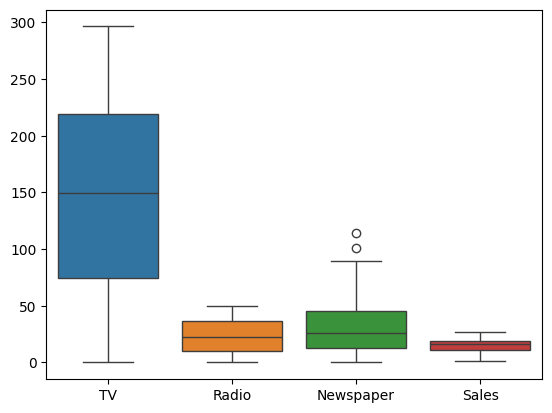

In [ ]:
sns.boxplot(df)

Check Distribution Of Newspaper column

/tmp/ipykernel_4920/3262100579.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Newspaper'])


<Axes: xlabel='Newspaper', ylabel='Density'>

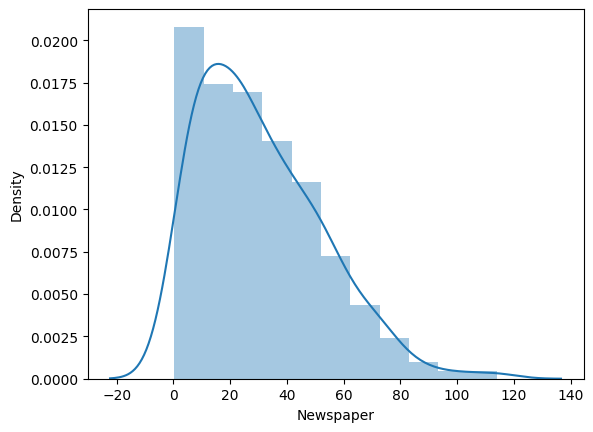

In [ ]:
sns.distplot(df['Newspaper'])

Dstribution Of Newspaper columns using Histogram

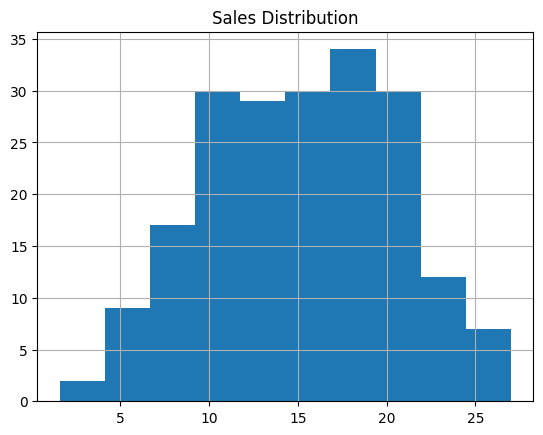

In [ ]:
df["Sales"].hist()
plt.title("Sales Distribution")
plt.show()

Pairplot

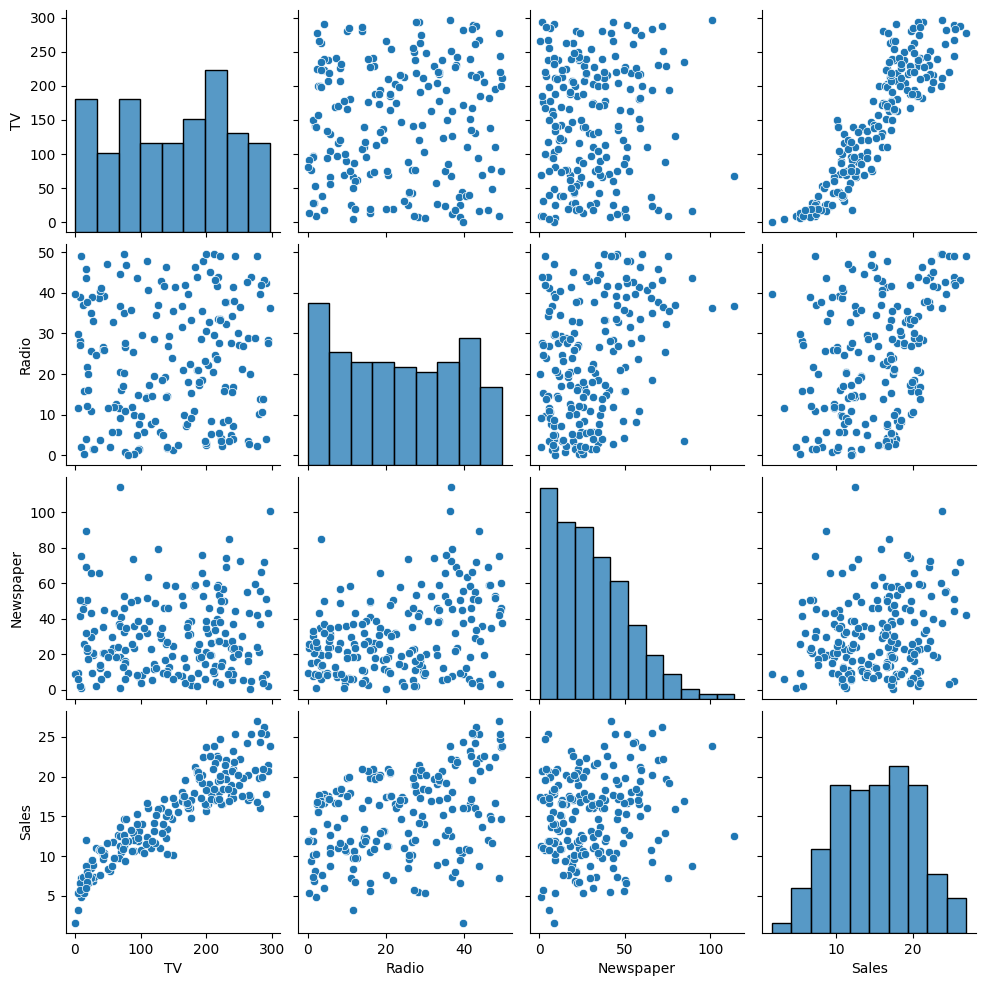

In [ ]:
sns.pairplot(df)
plt.show()

ScatterPlot

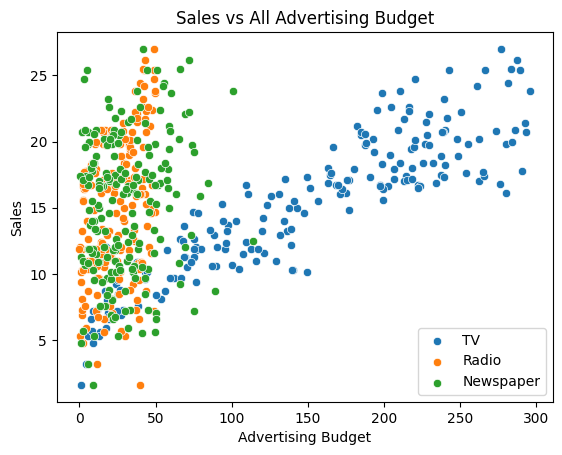

In [ ]:
sns.scatterplot(x='TV',y='Sales',data=df,label='TV')
sns.scatterplot(x='Radio',y='Sales',data=df,label='Radio')
sns.scatterplot(x='Newspaper',y='Sales',data=df,label='Newspaper')
plt.title('Sales vs All Advertising Budget')
plt.xlabel('Advertising Budget')
plt.legend()

BarPlot

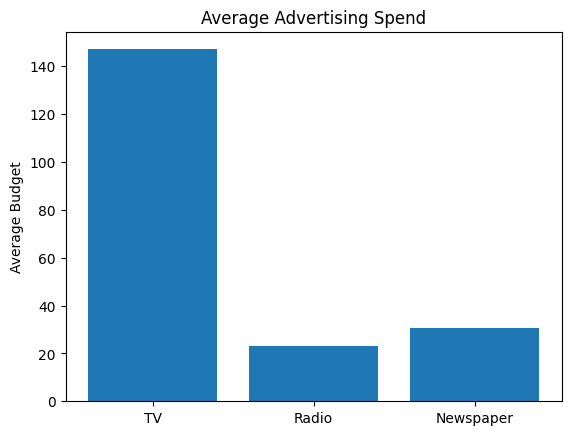

In [ ]:
avg_values = [
    df["TV"].mean(),
    df["Radio"].mean(),
    df["Newspaper"].mean()
]

labels = ["TV", "Radio", "Newspaper"]

plt.bar(labels, avg_values)

plt.ylabel("Average Budget")
plt.title("Average Advertising Spend")

plt.show()

HeatMap Showing Correlation

<Axes: >

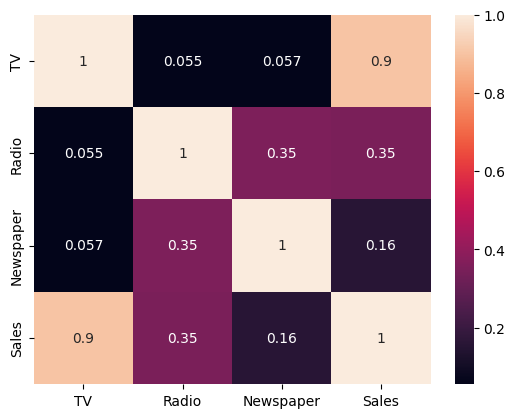

In [ ]:
sns.heatmap(df.corr(),annot=True)

In [ ]:
X=df.drop(columns=['Sales'],axis=1)
y=df['Sales']

Import Libaries

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

Convert data 80% train and 20% Test

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=42)

In [ ]:
scaler=StandardScaler()

In [ ]:
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

LinearRegression Model

In [ ]:
model=LinearRegression()

In [ ]:
model.fit(X_train,y_train)

LinearRegression()

In [ ]:
y_pred=model.predict(X_test)

In [ ]:
y_pred

array([17.0347724 , 20.40974033, 23.72398873,  9.27278518, 21.68271879,
       12.56940161, 21.08119452,  8.69035045, 17.23701254, 16.66657475,
        8.92396497,  8.4817344 , 18.2075123 ,  8.06750728, 12.64550975,
       14.93162809,  8.12814594, 17.89876565, 11.00880637, 20.47832788,
       20.80631846, 12.59883297, 10.9051829 , 22.38854775,  9.41796094,
        7.92506736, 20.83908497, 13.81520938, 10.77080925,  7.92682509,
       15.95947357, 10.63490851, 20.80292008, 10.43434164, 21.5784752 ,
       21.18364487, 12.12821771, 22.80953262, 12.60992766,  6.46441252])

Regression Plot Showing linearity

<Axes: xlabel='Sales'>

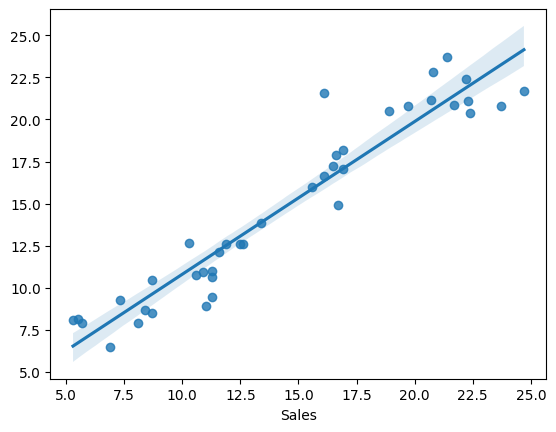

In [ ]:
sns.regplot(x=y_test,y=y_pred)

Accuracy of Model Using R2_Score

In [ ]:
print(r2_score(y_test,y_pred))

0.9059011844150825


Model Accuracy is 90%